In [2]:
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
import pickle
from spectral.io import envi
from collections import OrderedDict

from scipy.signal import medfilt, savgol_filter
from scipy.interpolate import splrep, splev, interp1d

from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_analytical
from isofit.configs import configs
from isofit.core.geometry import Geometry

%matplotlib widget

In [3]:
home = '/store/carroll/col/data/2018/'

fp = glob(os.path.join(home, 'test_flightlines', '*', 'output', '*_rfl.hdr'))[0]
wl = np.array([float(x) for x in envi.read_envi_header(fp)['wavelength']])
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

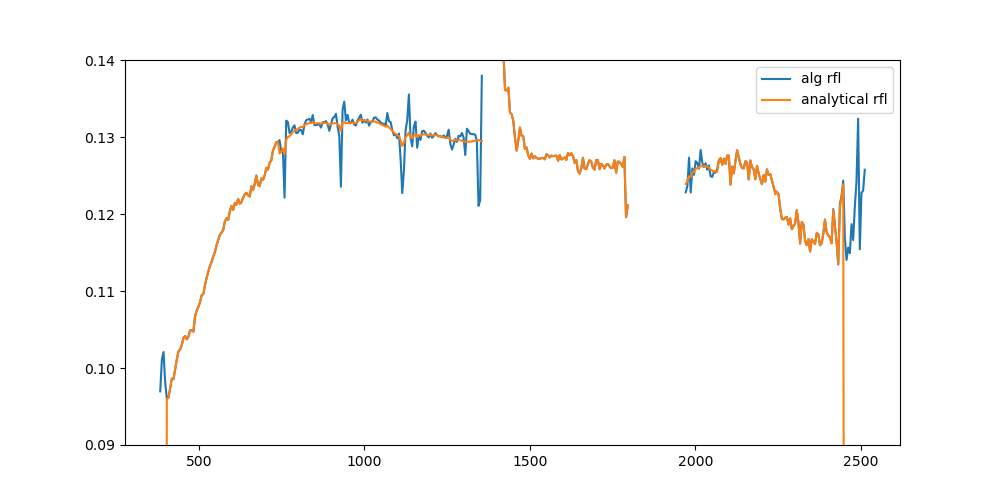

In [4]:
# load modeled rfl

fp = os.path.join(home, 'test_rccs', 'alg_rfl_blueline_postproces_withtrend_20250903.txt')
alg_rfl = np.loadtxt(fp)

fp = os.path.join(home, 'test_rccs', 'analytical_rfl_blueline_postproces_withtrend_20250903.txt')
analytical_rfl = np.loadtxt(fp)

fig = plt.figure(figsize=(10,5))
plt.plot(wl_nan, alg_rfl, label='alg rfl')
plt.plot(wl_nan, analytical_rfl, label='analytical rfl')
plt.ylim(0.09, 0.14)
plt.legend()
plt.show()

[  4  14  24  34  44  54  64  69  84  94 104 114 124 134 144 154 164 174
 184 192 224 234 244 264 274 278 319 324 328 334 340 354 364 374 384 394
 404]


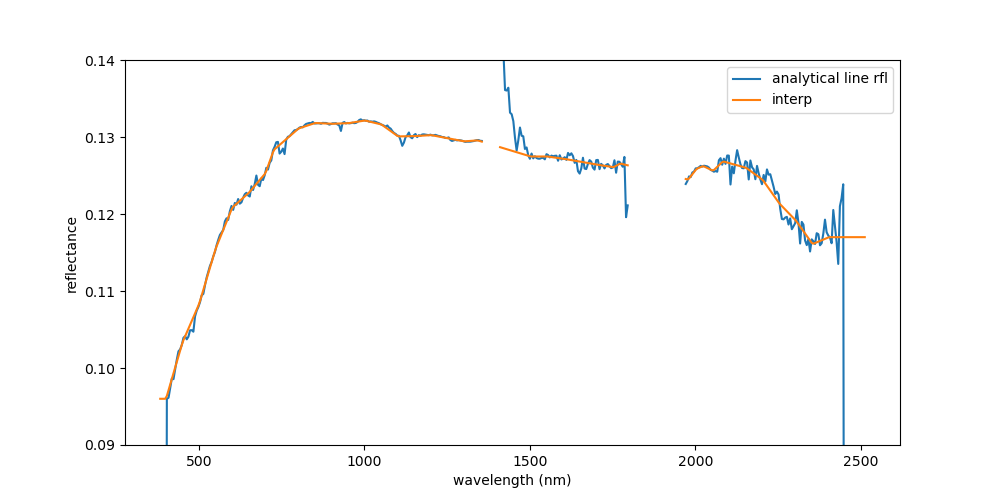

In [6]:
# get spline interpolation of the modeled rfl

bin_size = 2

exp_arr = np.arange(4, len(wl)+1, 10)
exp_arr = exp_arr[exp_arr!=74]
exp_arr[exp_arr==194] = 192
exp_arr = exp_arr[(exp_arr < 193) | (exp_arr > 223)]
exp_arr = exp_arr[exp_arr!=254]
exp_arr = exp_arr[(exp_arr < 280) | (exp_arr > 316)]
exp_arr[exp_arr==344] = 340
exp_arr = np.sort(np.append(exp_arr, [69,278,319,328]))
exp_arr = exp_arr[exp_arr<414]

exp_lis = [np.mean(wl[x-bin_size:x+bin_size]) for x in exp_arr]
rfl_lis = [np.mean(analytical_rfl[x-bin_size:x+bin_size]) for x in exp_arr]
rfl_lis[0] = analytical_rfl[4]
interp = np.interp(wl, exp_lis, rfl_lis)
# delta = analytical_rfl - interp

print(exp_arr)
fig = plt.figure(figsize=(10,5))

plt.plot(wl_nan, analytical_rfl, label='analytical line rfl')
# plt.scatter(exp_lis, rfl_lis, color='#ff7f0e')
plt.plot(wl_nan, interp, label='interp')

# plt.plot(analytical_rfl, label='raw rfl')
# # plt.scatter(exp_lis, rfl_lis, color='#ff7f0e')
# plt.plot(interp, label='interp')

plt.ylabel('reflectance')
plt.xlabel('wavelength (nm)')
plt.ylim(0.09, 0.14)
plt.legend()
plt.show()

# # export the interpolated modeled rfl
# fp_out = os.path.join(home, 'test_rccs', 'analytical_rfl_blueline_interp_20250908.txt')
# np.savetxt(fp_out, interp)

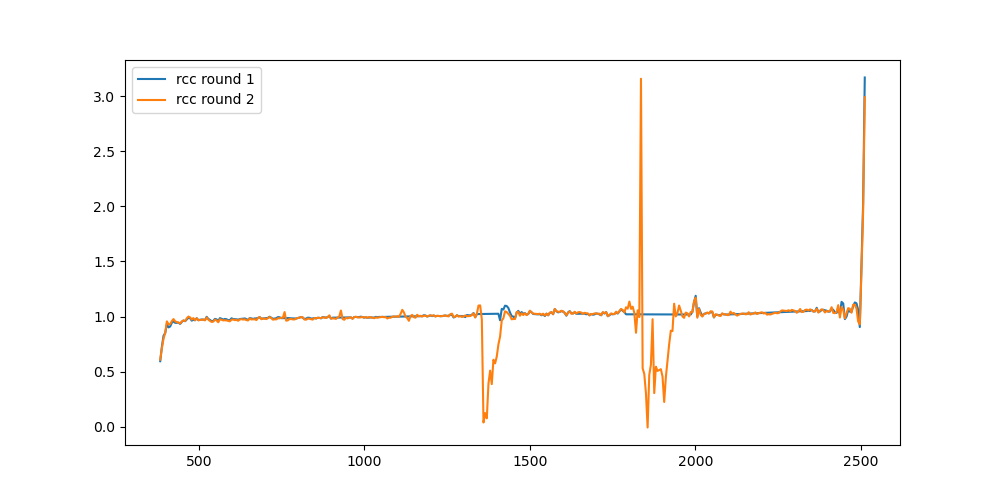

In [7]:
# send modeled rfl forward through isofit

fp = os.path.join(home, 'test_rccs', 'analytical_rfl_blueline_interp_20250908.txt')
interp_rfl = np.loadtxt(fp)

with open(os.path.join(home, 'test_rccs', 'single_pxs.pkl'), 'rb') as f:
    px = pickle.load(f)
flight = 'NIS01_20180620_170133'
k = 'dark'
target = px[flight][k]

working_dir = os.path.join(home, 'test_rccs', flight)

fp_config = glob(os.path.join(working_dir, 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp_config)

fm = ForwardModel(config)
io = IO(config, fm)
inv = Inversion(config, fm)

geom = Geometry(obs=target['obs'], loc=target['loc'])
geom.sky_view_factor = 1

states=inv.invert(target['rdn'], geom)
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, target['rdn'], geom)

modeled_rdn = fm.calc_meas(np.concatenate([x_alg, x_RT, x_instrument]), geom, interp_rfl)
rcc_round_2 = modeled_rdn/target['rdn']

# visual comparison w round 1 rccs
rcc_round_1 = np.loadtxt(os.path.join(home, 'test_roi', 'rcc_white_tarp_mean_postprocess_withtrend_20250903_wholeswir2.txt'))

fig = plt.figure(figsize=(10,5))

plt.plot(wl, rcc_round_1, label='rcc round 1')
plt.plot(wl, rcc_round_2, label='rcc round 2')

plt.legend()
plt.show()

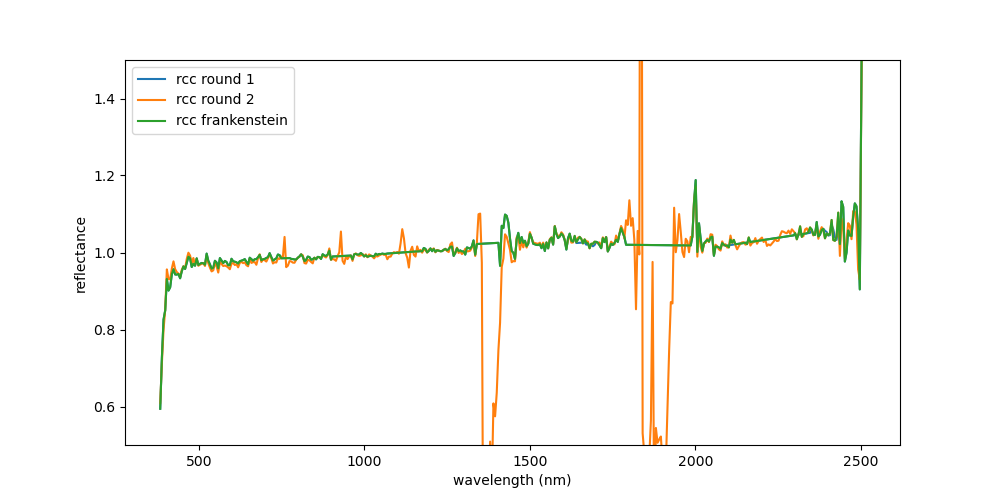

In [10]:
# frankenstein them

rcc_frankenstein = rcc_round_1.copy()

# replace some visually-determined wavelength regions of the original factors with the second set of factors
rcc_frankenstein[closest_wl(1640):closest_wl(1671)] = rcc_round_2[closest_wl(1640):closest_wl(1670)]
rcc_frankenstein[closest_wl(1685):closest_wl(1700)] = rcc_round_2[closest_wl(1685):closest_wl(1700)]
rcc_frankenstein[closest_wl(2102):closest_wl(2122)] = rcc_round_2[closest_wl(2102):closest_wl(2122)]
rcc_frankenstein[closest_wl(2157):closest_wl(2166)] = rcc_round_2[closest_wl(2157):closest_wl(2166)]
rcc_frankenstein[closest_wl(2303):closest_wl(2321)+1] = rcc_round_2[closest_wl(2303):closest_wl(2321)+1]
rcc_frankenstein[closest_wl(2342):closest_wl(2352)] = rcc_round_2[closest_wl(2342):closest_wl(2352)]
rcc_frankenstein[closest_wl(2392):closest_wl(2437)] = rcc_round_2[closest_wl(2392):closest_wl(2437)]

# further manual adjustment...
rcc_frankenstein[closest_wl(1635)] = rcc_frankenstein[closest_wl(1635)]*1.005
rcc_frankenstein[closest_wl(1646)] = rcc_frankenstein[closest_wl(1646)]*0.995
rcc_frankenstein[closest_wl(1671)] = rcc_frankenstein[closest_wl(1671)]*1.005
rcc_frankenstein[closest_wl(2106)] = rcc_frankenstein[closest_wl(2106)]*0.99

rcc_changes = [[1640, 1671], [1685,1700], [2102,2122], [2157,2166], [2303,2321], [2342,2352], [2392,2437]]

fig = plt.figure(figsize=(10,5))

plt.plot(wl, rcc_round_1, label='rcc round 1')
plt.plot(wl, rcc_round_2, label='rcc round 2')
plt.plot(wl, rcc_frankenstein, label='rcc frankenstein')

plt.ylabel('reflectance')
plt.xlabel('wavelength (nm)')
plt.ylim(0.5, 1.5)

plt.legend()
plt.show()

In [72]:
# export

fp_out = os.path.join(home, 'test_rccs', 'rcc_frankenstein_20250908.txt')
np.savetxt(fp_out, rcc_frankenstein)

In [16]:
ignore_zones = [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.34, 1.410], [1.640,1.670], [1.79, 1.99], # water absorption regions (narrower)
                # [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.33, 1.465], [1.77, 2.05], # water absorption regions
                [0.669, 0.679],
                [2.096, 2.350]] # identified systematics - most conservative

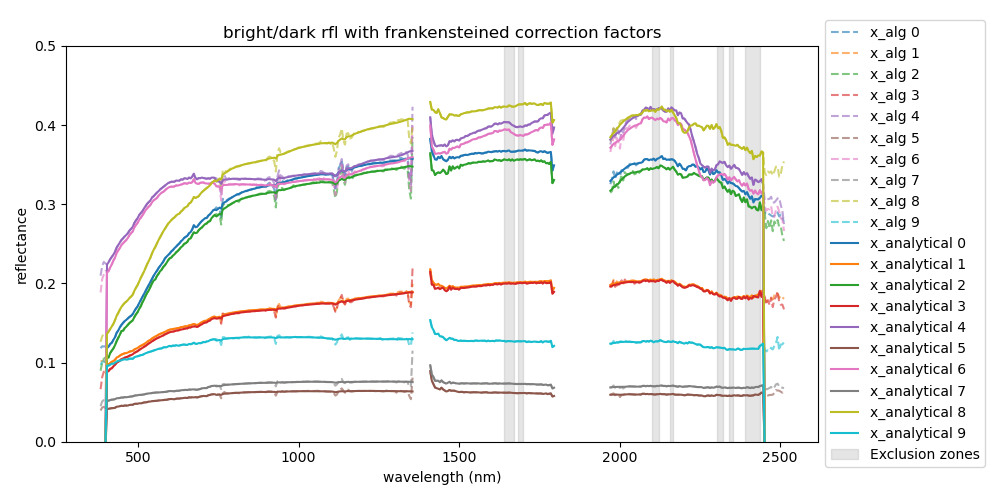

In [75]:
# test frankenstein rcc set

fp = os.path.join(home, 'test_rccs', 'rcc_frankenstein_20250908.txt')
rcc_frankenstein = np.loadtxt(fp)
rcc = rcc_frankenstein

base_dir = os.path.join(home, 'test_rccs/')

# isofit dirs
test_flights = [x for x in os.listdir(base_dir) if x.startswith('NIS')]
with open(os.path.join(home, 'test_rccs/single_pxs.pkl'), 'rb') as f:
    bright_dark_px = pickle.load(f)

alg_rfl = []
analytical_rfl = []

for flight_id in test_flights:
    for k in ['bright', 'dark']:
        working_dir = glob(os.path.join(base_dir, f'{flight_id}*'))[0]
        
        rdn = bright_dark_px[flight_id][k]['rdn']
        obs = bright_dark_px[flight_id][k]['obs']
        loc = bright_dark_px[flight_id][k]['loc']
        
        # load config as-is
        fp_config = os.path.join(working_dir, 'config', f'{flight_id}_isofit.json')
        config = configs.create_new_config(fp_config)
        
        # set up forward model, io, inversion according to config
        fm = ForwardModel(config)
        io = IO(config, fm)
        inv = Inversion(config, fm)
        
        # load the isofit geometry representation of the single pixel
        geom = Geometry(obs=obs, loc=loc)
        geom.sky_view_factor = 1 # updated isofit dev 8/20 and now this is necessary? Not sure why skyview factor is no longer automatically populating to 1 when none provided
        
        # adjust rdn
        meas = rdn.copy()
        meas = meas*rcc
        
        # retrieve rfl
        states=inv.invert(meas, geom)
        xa_surface = fm.surface.xa(states[0,...][fm.idx_surface].copy(), geom) # get surface prior mean
        x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
        x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
        rfl_est = fm.surface.fit_params(x_alg, geom)
        x0 = np.concatenate([rfl_est, x_RT, x_instrument])
        states, unc, EXIT_CODE = invert_analytical(inv.fm, inv.winidx, meas, geom, np.copy(x0), states[-1,:], num_iter = 1, hash_table = OrderedDict(), hash_size = 500)
        out_rfl_est = states[-1, fm.idx_surf_rfl]
        
        alg_rfl.append(x_alg)
        analytical_rfl.append(out_rfl_est)

# viz solutions

fig = plt.figure(figsize=(10,5))

for i in range(len(alg_rfl)):
    plt.plot(wl_nan, alg_rfl[i], label=f'x_alg {i}', alpha=0.6, ls='--')
for i in range(len(alg_rfl)):
    plt.plot(wl_nan, analytical_rfl[i], label=f'x_analytical {i}')

# for _el, el in enumerate(ignore_zones):
#     if _el == 0:
#         plt.fill_between(np.array(el)*1000, 0, 0.5, color='grey', alpha=0.2, label='Exclusion zones')
#     else:
#         plt.fill_between(np.array(el)*1000, 0, 0.5, color='grey', alpha=0.2)

for _el, el in enumerate(rcc_changes):
    if _el == 0:
        plt.fill_between(np.array(el), 0, 0.5, color='grey', alpha=0.2, label='Exclusion zones')
    else:
        plt.fill_between(np.array(el), 0, 0.5, color='grey', alpha=0.2)
                
plt.ylabel('reflectance')
plt.xlabel('wavelength (nm)')
plt.ylim(0, 0.5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.title('bright/dark rfl with frankensteined correction factors')
plt.show()

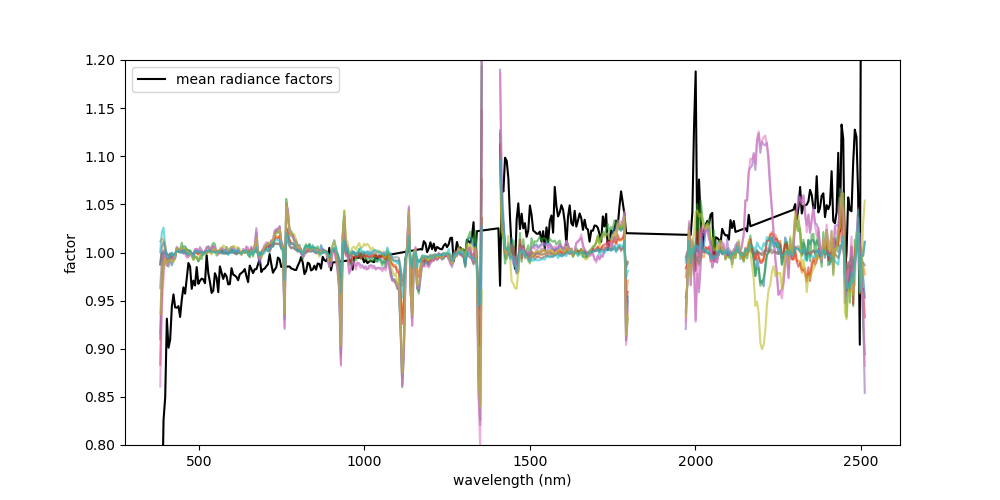

In [74]:
# check one more time for remaining systematics

# visualize the delta between x_alg (from the rcc-adjusted rdn) and a smoothed linear interpolation of x_alg
# compare those deltas w/ rccs, across all bright/dark targets
# regions where the noise (deltas) are similar across targets and follow the trends of the rccs = regions we want to interpolate across

deltas = []

fig = plt.figure(figsize=(10,5))

exp_arr = np.array([5,10,13,20,27,35,42,50,60,75,85,100,150,180,210,220,250,260,280,320,340,350,380,400,420])
bin_size = 2
exp_lis = [np.mean(wl_nan[x-bin_size:x+bin_size]) for x in exp_arr]

plt.plot(wl, rcc, color='black', label='mean radiance factors')

for i in range(len(alg_rfl)):
    rfl_lis = [np.mean(alg_rfl[i][x-bin_size:x+bin_size]) for x in exp_arr]
    interp = np.interp(wl_nan, exp_lis, rfl_lis)
    delta = alg_rfl[i] - interp
    deltas.append(delta)
    plt.plot(wl_nan, delta*5+1, alpha=0.6)
plt.ylabel('factor')
plt.xlabel('wavelength (nm)')
plt.ylim(0.8, 1.2)
plt.legend()
plt.show()

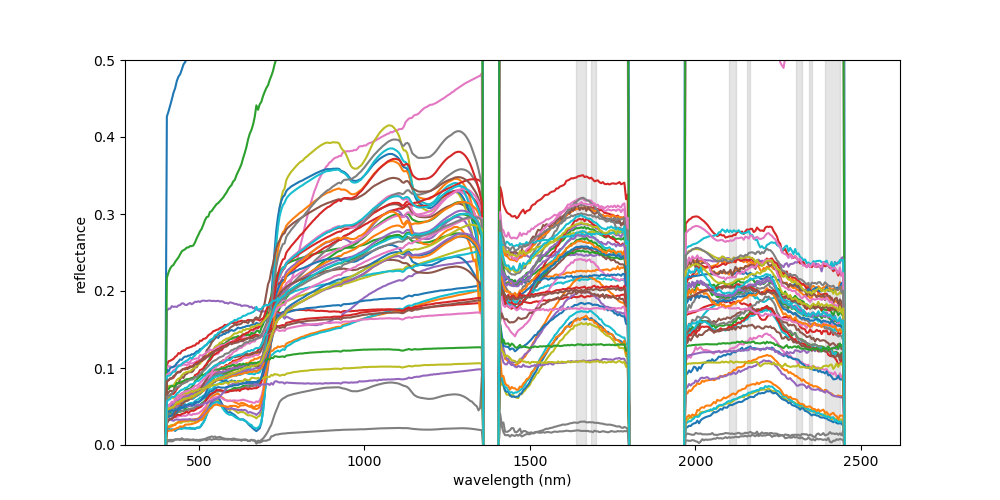

In [82]:
# test them on some random pixels (10 px from each of the test flights I identified earlier)

# rcc = np.loadtxt(os.path.join(home, 'test_rccs', 'rcc_frankenstein_20250908.txt'))

# subset_folder = os.path.join(home, 'test_rccs', 'subsets')
# flights = list(set(['_'.join(x.split('_')[:3]) for x in os.listdir(subset_folder) if x.startswith('NIS')]))
# n_sample = 10

# alg_rfl = []
# analytical_rfl = []

# for flight in flights:
#     working_dir = os.path.join(home, 'test_rccs', flight)
#     rdn = envi.open(os.path.join(subset_folder, f'{flight}_rdn.hdr')).open_memmap()
#     obs = envi.open(os.path.join(subset_folder, f'{flight}_obs.hdr')).open_memmap()
#     loc = envi.open(os.path.join(subset_folder, f'{flight}_igm.hdr')).open_memmap()
    
#     rows = np.random.randint(0, rdn.shape[0], size=n_sample)
#     cols = np.random.randint(0, rdn.shape[1], size=n_sample)

#     for i in range(n_sample):
#         rdn_ = rdn[rows[i], cols[i], :].copy()
#         obs_ = obs[rows[i], cols[i], :].copy()
#         loc_ = loc[rows[i], cols[i], :].copy()

#         fp_config = os.path.join(working_dir, 'config', f'{flight}_isofit.json')
#         config = configs.create_new_config(fp_config)
        
#         # set up forward model, io, inversion according to config
#         fm = ForwardModel(config)
#         io = IO(config, fm)
#         inv = Inversion(config, fm)
        
#         # load the isofit geometry representation of the single pixel
#         geom = Geometry(obs=obs_, loc=loc_)
#         geom.sky_view_factor = 1 # updated isofit dev 8/20 and now this is necessary? Not sure why skyview factor is no longer automatically populating to 1 when none provided
        
#         # adjust rdn
#         meas = rdn_.copy()
#         meas = meas*rcc
        
#         # retrieve rfl
#         states=inv.invert(meas, geom)
#         xa_surface = fm.surface.xa(states[0,...][fm.idx_surface].copy(), geom) # get surface prior mean
#         x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
#         x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
#         rfl_est = fm.surface.fit_params(x_alg, geom)
#         x0 = np.concatenate([rfl_est, x_RT, x_instrument])
#         states, unc, EXIT_CODE = invert_analytical(inv.fm, inv.winidx, meas, geom, np.copy(x0), states[-1,:], num_iter = 1, hash_table = OrderedDict(), hash_size = 500)
#         out_rfl_est = states[-1, fm.idx_surf_rfl]
        
#         alg_rfl.append(x_alg)
#         analytical_rfl.append(out_rfl_est)

# viz solutions
fig = plt.figure(figsize=(10,5))

# for i in range(len(alg_rfl)):
#     plt.plot(wl_nan, alg_rfl[i], label=f'x_alg {i}', alpha=0.6, ls='--')
for i in range(len(alg_rfl)):
    plt.plot(wl, analytical_rfl[i], label=f'x_analytical {i}')

for _el, el in enumerate(rcc_changes):
    if _el == 0:
        plt.fill_between(np.array(el), 0, 0.5, color='grey', alpha=0.2, label='rccs updated')
    else:
        plt.fill_between(np.array(el), 0, 0.5, color='grey', alpha=0.2)
        

plt.ylabel('reflectance')
plt.xlabel('wavelength (nm)')
plt.ylim(0, 0.5)
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# plt.tight_layout()
# plt.title('bright/dark rfl with frankensteined correction factors')
plt.show()

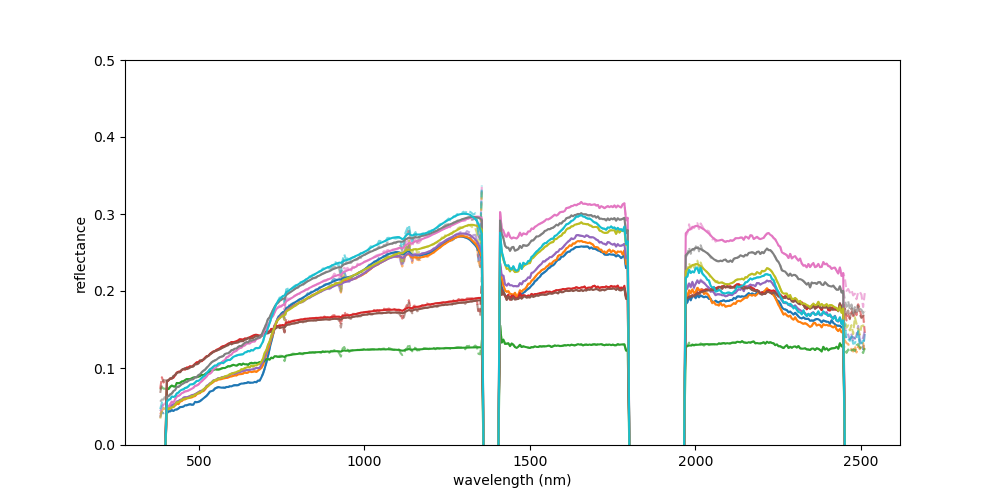

In [88]:
# viz solutions
fig = plt.figure(figsize=(10,5))

for i in range(40,50):
    plt.plot(wl_nan, alg_rfl[i], label=f'x_alg {i}', alpha=0.6, ls='--')
for i in range(40,50):
    plt.plot(wl, analytical_rfl[i], label=f'x_analytical {i}')

plt.ylabel('reflectance')
plt.xlabel('wavelength (nm)')
plt.ylim(0, 0.5)
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# plt.tight_layout()
# plt.title('bright/dark rfl with frankensteined correction factors')
plt.show()

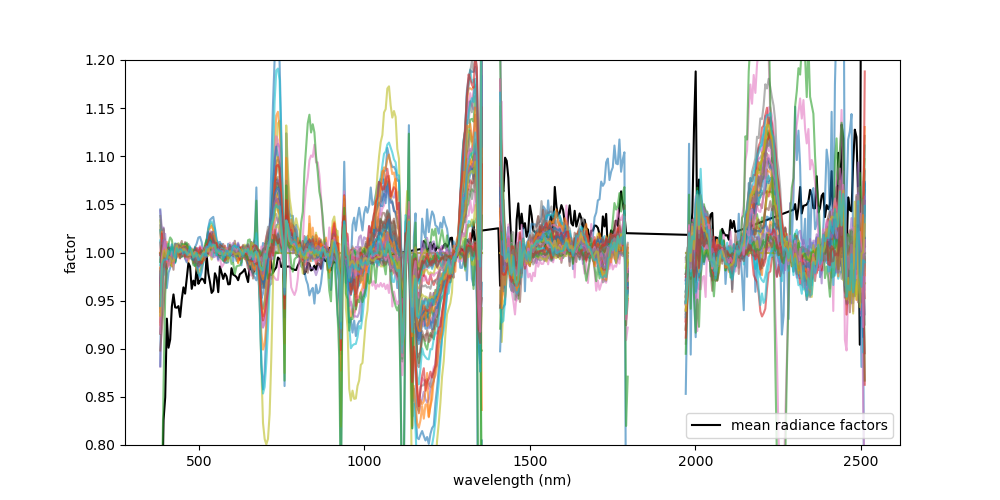

In [77]:
# check again for remaining systematics

# visualize the delta between x_alg (from the rcc-adjusted rdn) and a smoothed linear interpolation of x_alg
# compare those deltas w/ rccs, across all bright/dark targets
# regions where the noise (deltas) are similar across targets and follow the trends of the rccs = regions we want to interpolate across

deltas = []

fig = plt.figure(figsize=(10,5))

exp_arr = np.array([5,10,13,20,27,35,42,50,60,75,85,100,150,180,210,220,250,260,280,320,340,350,380,400,420])
bin_size = 2
exp_lis = [np.mean(wl_nan[x-bin_size:x+bin_size]) for x in exp_arr]

plt.plot(wl, rcc, color='black', label='mean radiance factors')

for i in range(len(alg_rfl)):
    rfl_lis = [np.mean(alg_rfl[i][x-bin_size:x+bin_size]) for x in exp_arr]
    interp = np.interp(wl_nan, exp_lis, rfl_lis)
    delta = alg_rfl[i] - interp
    deltas.append(delta)
    plt.plot(wl_nan, delta*5+1, alpha=0.6)
plt.ylabel('factor')
plt.xlabel('wavelength (nm)')
plt.ylim(0.8, 1.2)
plt.legend()
plt.show()